In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples = 1000,centers = 3, n_features = 2)

In [3]:
X

array([[  3.50420328,  -0.08972498],
       [  3.25311754,  -5.99354611],
       [  3.50567457, -11.26953186],
       ...,
       [  2.91481419,  -7.88417185],
       [  4.6922557 ,  -5.95126679],
       [  2.72188095,   1.0711005 ]], shape=(1000, 2))

In [4]:
y

array([0, 2, 1, 2, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 2,
       0, 0, 1, 1, 0, 1, 0, 2, 2, 0, 1, 2, 0, 0, 2, 1, 1, 1, 0, 2, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2, 0, 2, 2, 2, 1, 0, 0, 1,
       2, 0, 2, 2, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 2, 1, 1, 0, 0,
       1, 2, 1, 0, 0, 1, 2, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 2, 0, 1, 1, 1,
       1, 0, 0, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 2, 1, 0, 2, 2, 2, 0, 2, 0,
       0, 1, 2, 0, 2, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 1, 2,
       0, 2, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 2, 2, 2, 2, 0, 0, 2, 2, 0,
       2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1,
       1, 2, 1, 1, 0, 2, 2, 0, 0, 1, 0, 1, 2, 2, 2, 0, 0, 2, 1, 2, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 2, 2, 1, 0, 2, 0, 1, 2, 1, 0, 1, 0, 2, 1, 1,
       0, 1, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 2, 0, 0, 1, 1, 0, 2, 0, 0,
       2, 1, 2, 1, 1, 1, 0, 1, 0, 1, 1, 0, 2, 2, 0, 1, 2, 0, 2, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 2, 1, 0, 0, 0, 2, 2, 0, 0,

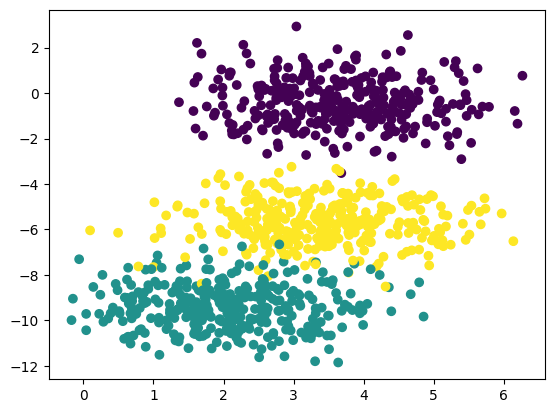

In [9]:
plt.scatter(X[:,0], X[:,1], c = y)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [10]:
# standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.cluster import KMeans

In [15]:
# Elbow method to select k value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [16]:
wcss

[1400.0000000000016,
 640.5557378619512,
 440.90278882550206,
 326.3105515743086,
 250.3329026863969,
 196.44056119490438,
 170.54518173395917,
 144.19089232582496,
 118.23889459440107,
 108.50168535852018]

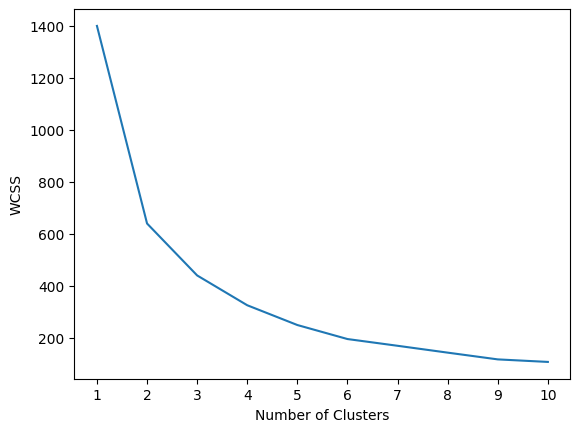

In [29]:
# plot elbow curve
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [30]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')

In [31]:
kmeans.fit_predict(X_train_scaled)

array([2, 2, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2,
       0, 0, 1, 2, 2, 1, 0, 0, 0, 1, 2, 1, 2, 0, 0, 2, 1, 2, 2, 0, 1, 2,
       2, 2, 0, 1, 0, 2, 1, 0, 1, 1, 0, 1, 2, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 2, 0, 1, 2, 0, 0, 0, 2, 2, 2, 2, 0, 0, 0, 1, 1, 2,
       0, 2, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 2, 0, 2, 0, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2,
       0, 2, 2, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 2, 1, 0, 1,
       1, 0, 1, 0, 0, 2, 0, 1, 2, 0, 2, 2, 0, 2, 0, 0, 1, 2, 0, 2, 0, 1,
       0, 1, 0, 1, 2, 0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2,
       2, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 2, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 2,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1,

In [32]:
y_pred = kmeans.predict(X_test_scaled)

In [33]:
y_pred

array([1, 0, 2, 0, 1, 0, 2, 2, 2, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 2, 2, 2, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2,
       2, 0, 1, 2, 2, 1, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 2, 0, 0, 1,
       0, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 0, 0, 0, 0, 1, 2, 2, 0, 0, 1, 0,
       2, 2, 1, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 2, 2, 1, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 1, 2, 0, 1, 0,
       0, 2, 2, 1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 0, 2, 2, 2, 1, 2, 1, 0,
       1, 2, 0, 0, 0, 1, 2, 1, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       2, 1, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 0, 2,
       2, 2, 1, 0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 1, 1, 2, 2, 0, 0, 1, 1, 2,
       1, 0, 1, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1, 0, 1, 2, 0, 1, 0, 2, 0, 1,
       1, 2, 0, 0, 0, 1, 0, 2, 2, 0, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       2, 1, 1, 2, 0, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 1, 0,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1], d

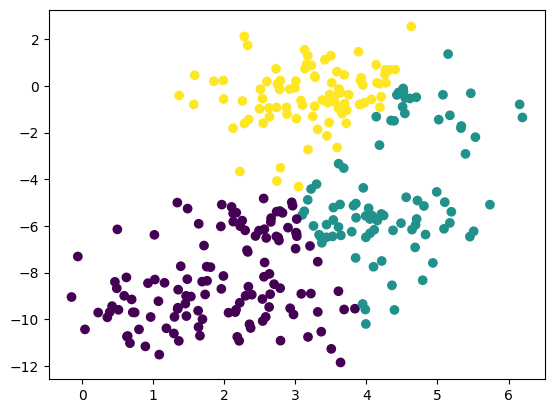

In [34]:
plt.scatter(X_test[:,0], X_test[:,1], c = y_pred)

In [35]:
# Validating the k value
# kneelocator
# silhoutee scoring

In [36]:
# kneelocator
!pip install kneed


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from kneed import KneeLocator

In [38]:
kl = KneeLocator(range(1, 11), wcss, curve = 'convex', direction = 'decreasing')

In [39]:
kl.elbow

np.int64(3)

In [41]:
# silhouette score
from sklearn.metrics import silhouette_score

In [43]:
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, init = "k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [44]:
silhouette_coefficients

[0.45523334651985337,
 0.420596727767359,
 0.40677923054034054,
 0.3815505337157338,
 0.3788441291649599,
 0.41401966377813004,
 0.37813029540821985,
 0.4149132467861645,
 0.3988127173386703]

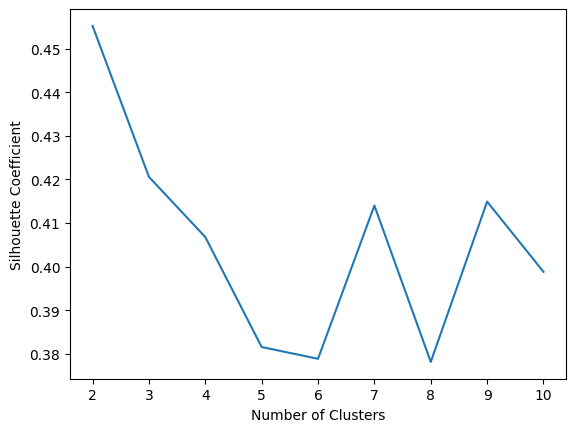

In [45]:
# plot silhouette score
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()